# Oppgave 5.1 Kundeadferd med tilbud på varer 
Som vist nedenfor har jeg laget en oversikt over om tilbud på varer påvirker salg og omsetning. Denne oppgaven undersøker hvordan 
tilbud på en vare i en butikk påvirker salg og inntekter. Vi ønsker å finne ut om kunder kjøper mer når varene er på salg. 

Vi startet med å lage en liste over ulike varer med fastsatte priser og sjansen for at de blir kjøpt. Hver vare hadde en spesefikk 
sannsynlighet for salg. For eksempel har "pølse" en sjanse på 2% for kjøp, mens "brød" har en sjanse på 30%. Deretter satt vi inn en logisktisk modell for å øke sjansen for kjøp når varer kommer på tilbud. Det er med på å få fram tydlig hvordan tilbud påvirker kundeadferden. Vi simulerte en dag i butikken og deretter fortsatte å simulere en måned både med og uten tilbud på varer, det blir registert antall salg og inntekter for hver dag. Til slutt la vi inn en gjennomsnittsmåler som viser salg og inntekter for begge scenariene. Dette ga oss et klart bilde på hvordan tilbudene påvirker resultanene. 

Gjennomsnittlig salg uten tilbud: 32.87
Gjennomsnittlig salg med tilbud: 39.70
Gjennomsnittlig inntekt uten tilbud: 1436.00 NOK
Gjennomsnittlig inntekt med tilbud: 1911.00 NOK


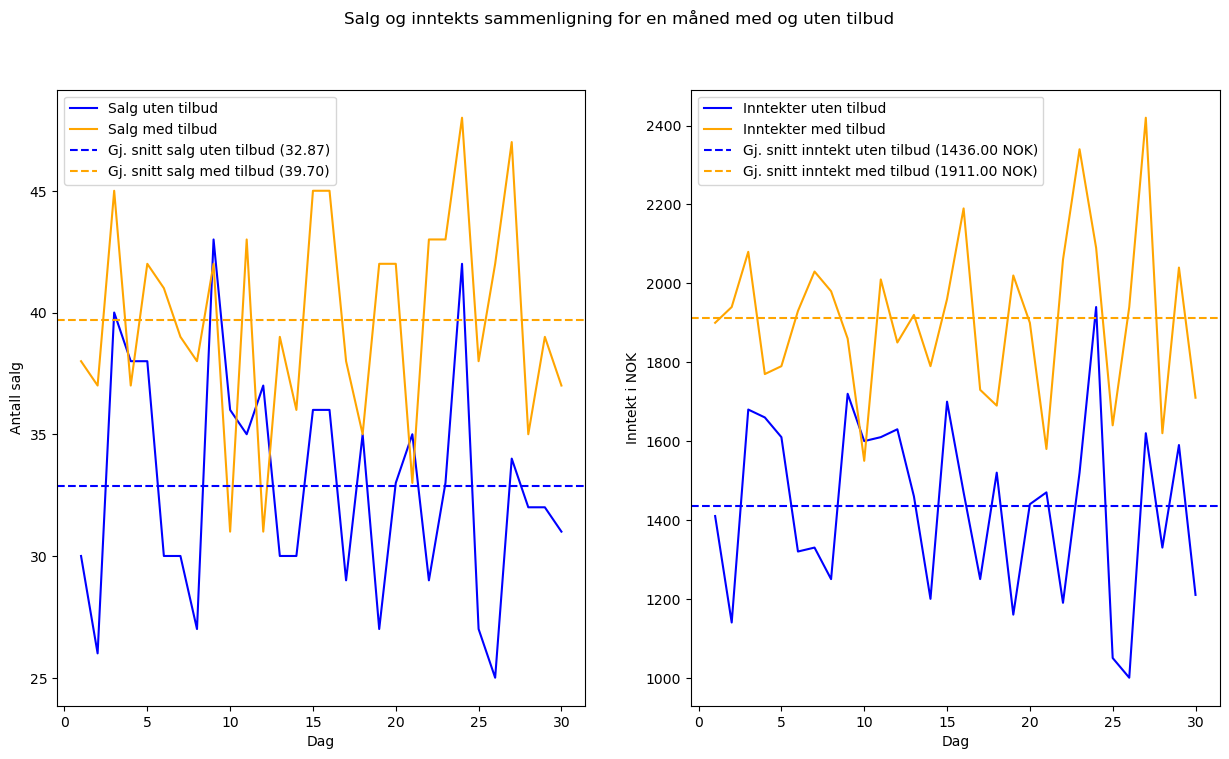

In [3]:
# Koden for oppgave 5.1

import random
import numpy as np 
import matplotlib.pyplot as plt 

# Varer med pris
varer = {"pølse": 70, "avokado": 40, "rømme": 30, "brød": 40, "kjøtt": 120}
sannsynlighet_for_kjøp = {"pølse": 0.02, "avokado": 0.1, "rømme": 0.09, "brød": 0.3, "kjøtt": 0.04}

# Definisjon av tilbudsrate og logistiske modellparameter
tilbudsrate = 0.3 
logistisk = 20 

def logistisk_økning(sannsynlighet, tilbudsrate): 
    return sannsynlighet + (1 - sannsynlighet) / (1 + np.exp(-logistisk * (tilbudsrate - 0.5)))

# Utfør beregninger av høynet sjanser med tilbud
tilbudssjanse = {vare: logistisk_økning(sannsynlighet, tilbudsrate) for vare, sannsynlighet in sannsynlighet_for_kjøp.items()}

# Simulering av en dag
def simuler_dag(varer, sannsynligheter, kunder):
    totale_salg = 0 
    totale_inntekter = 0 

    for _ in range(kunder): 
        budsjett = random.gauss(600, 150)
        for vare, pris in varer.items(): 
            if random.random() < sannsynligheter[vare] and budsjett >= pris:
                totale_salg += 1 
                totale_inntekter += pris 
                budsjett -= pris 

    return totale_salg, totale_inntekter

# Simulering av en måned (30 dager) med og uten tilbud
dager = 30 
kunder_daglig = 60 

salg_uten_tilbud = []
inntekter_uten_tilbud = []
salg_med_tilbud = []
inntekter_med_tilbud = []

for _ in range(dager): 
    salg, inntekter = simuler_dag(varer, sannsynlighet_for_kjøp, kunder_daglig)
    salg_uten_tilbud.append(salg)
    inntekter_uten_tilbud.append(inntekter)

    salg, inntekter = simuler_dag(varer, tilbudssjanse, kunder_daglig)
    salg_med_tilbud.append(salg)
    inntekter_med_tilbud.append(inntekter)

# Beregning av gjennomsnittlig salg og inntekter
gj_salg_uten_tilbud = np.mean(salg_uten_tilbud)
gj_inntekter_uten_tilbud = np.mean(inntekter_uten_tilbud)
gj_salg_med_tilbud = np.mean(salg_med_tilbud)
gj_inntekter_med_tilbud = np.mean(inntekter_med_tilbud)

# Skriv inn resultatene 
dager_resultat = list(range(1, dager + 1))

plt.figure(figsize=(15, 8))

# Plott for antall salg
plt.subplot(1, 2, 1)
plt.plot(dager_resultat, salg_uten_tilbud, label="Salg uten tilbud", color='blue')
plt.plot(dager_resultat, salg_med_tilbud, label="Salg med tilbud", color='orange')
plt.axhline(gj_salg_uten_tilbud, color='blue', linestyle='--', label=f"Gj. snitt salg uten tilbud ({gj_salg_uten_tilbud:.2f})")
plt.axhline(gj_salg_med_tilbud, color='orange', linestyle='--', label=f"Gj. snitt salg med tilbud ({gj_salg_med_tilbud:.2f})")
plt.xlabel("Dag") 
plt.ylabel("Antall salg")
plt.legend()

# Plott for inntekter
plt.subplot(1, 2, 2)
plt.plot(dager_resultat, inntekter_uten_tilbud, label="Inntekter uten tilbud", color='blue')
plt.plot(dager_resultat, inntekter_med_tilbud, label="Inntekter med tilbud", color='orange')
plt.axhline(gj_inntekter_uten_tilbud, color='blue', linestyle='--', label=f"Gj. snitt inntekt uten tilbud ({gj_inntekter_uten_tilbud:.2f} NOK)")
plt.axhline(gj_inntekter_med_tilbud, color='orange', linestyle='--', label=f"Gj. snitt inntekt med tilbud ({gj_inntekter_med_tilbud:.2f} NOK)")
plt.xlabel("Dag")
plt.ylabel("Inntekt i NOK")
plt.legend()

plt.suptitle("Salg og inntekts sammenligning for en måned med og uten tilbud")

# Vis gjennomsnittsresultatene i konsollen
print(f"Gjennomsnittlig salg uten tilbud: {gj_salg_uten_tilbud:.2f}")
print(f"Gjennomsnittlig salg med tilbud: {gj_salg_med_tilbud:.2f}")
print(f"Gjennomsnittlig inntekt uten tilbud: {gj_inntekter_uten_tilbud:.2f} NOK")
print(f"Gjennomsnittlig inntekt med tilbud: {gj_inntekter_med_tilbud:.2f} NOK")

plt.show()


# Resultat
Fra grafene ovenfor kan vi se hvor mye av salget og inntektene øker når varene settes på tilbud. Når det ikke var tilbud på varene
var det gjennomsnittlige salget på 32.87 varer pr dag. Det vil si at butikken solgte 33 varer daglig uten noen form for rabatt. 
Når derimot varene ble satt på tilbud økte gjennomsnittet til 39.70 varer pr dag. Dette resultatet viser tydelig at tilbud på varer har en effekt på salget.

På den andre siden har vi inntekter. Den gjennomsnittlige inntekten uten tilbud er på 1436kr pr dag. Når salget er på rundt 33 varer pr dag, tilsier det ca. 43kr per solgte vare. Når varene kom på tilbud økte den gjennomsnittlige inntekten til 1911kr pr dag. Som viser at tilbudene ikke bare økte salget, men også inntektene. Selv om varene ble solgt til lavere priser, ble inntekten større med en høyrer antall solgte varer. 

# Diskujon 
Resultanene vi fikk viser at rabatter øker både salg og inntekter, dette bekrefter at kunder blir påvirket av tilbud. Det er en veldig relevant oppgave, da det illusterer noe av det matvarebutikkene gjør hver dag (analyserer kundeadferd). En styrke i denne oppgaven er at resultanene viser stor korrelasjon mellom tilbud og salg. Det er også gode visuelle grafer, som viser salg og inntekter hver for seg på en forstålig måte. På den andre siden kan noen av svakhetene være at dette var et utvalg og ikke en stø. Oppgaven tar heller ikke for seg kostnadene ved rabatter, som potensielt kan minke butikkens fortjeneste. Skal en butikk kunne dra noe informasjon ut ifra en slik graf må den være mye mer kompleks og ta hensyn til kundeadferd og dynamikken i markedet. 